# 04 - Job Clustering & Skill-Gap Report (Unsupervised)
Discovers natural job/role families via K-Means on the job corpus, then uses cluster membership to power the skill-gap ('CV preparation') report.

In [1]:
import sys
sys.path.append('..')
from src.models.clustering import run_clustering

kmeans, svd, corpus, terms = run_clustering()

SVD: (69991, 15000) -> (69991, 100), explained variance=0.163


k= 4 | inertia=    9861.0 | silhouette=0.0308


k= 6 | inertia=    9350.9 | silhouette=0.0399


k= 8 | inertia=    9121.5 | silhouette=0.0315


k=10 | inertia=    8712.3 | silhouette=0.0477


...

k=18 | inertia=    8104.8 | silhouette=0.0385


k=20 | inertia=    7926.1 | silhouette=0.0537


Saved -> /home/claude/smarthire/reports/figures/clustering_k_selection.png

Selected k=20 (best silhouette)



Top terms per cluster:
  Cluster  0 (n= 6034): status, employment, gender, protected, disability, national, origin, race
  Cluster  1 (n= 7059): work, service, time, equipment, experience, position, required, company
  Cluster  2 (n= 5042): care, patient, health, patients, nursing, health care, nurse, provider
  Cluster  3 (n= 2864): developer, web, net, javascript, php, css, html, jquery
  Cluster  4 (n= 7916): project, management, business, experience, team, skills, projects, work
  Cluster  5 (n= 2057): accounting, financial, finance, accounts, accountant, tax, auditing, accounting auditing
  Cluster  6 (n= 5481): sales, business, manager, business development, marketing, new, development, customer
  Cluster  7 (n=10354): candidate, experience, profile, good, years, job, location, candidate profile
  Cluster  8 (n=  189): incentives, inbound, fixed, fixed salary, bonus rs, calls, loyalty bonus, tech
  Cluster  9 (n= 7893): experience, design, software, data, development, technical,

Saved -> /home/claude/smarthire/reports/figures/clustering_pca_scatter.png


## k selection
Elbow (inertia) and silhouette score computed for k in {4,6,...,20}. See `reports/figures/clustering_k_selection.png`. Silhouette scores are low overall (~0.03-0.05) which is typical for sparse, high-dimensional TF-IDF text data with generic boilerplate phrases (EEO clauses, generic 'requirements' language) diluting cluster cohesion -- the clusters are still qualitatively meaningful, as shown below.

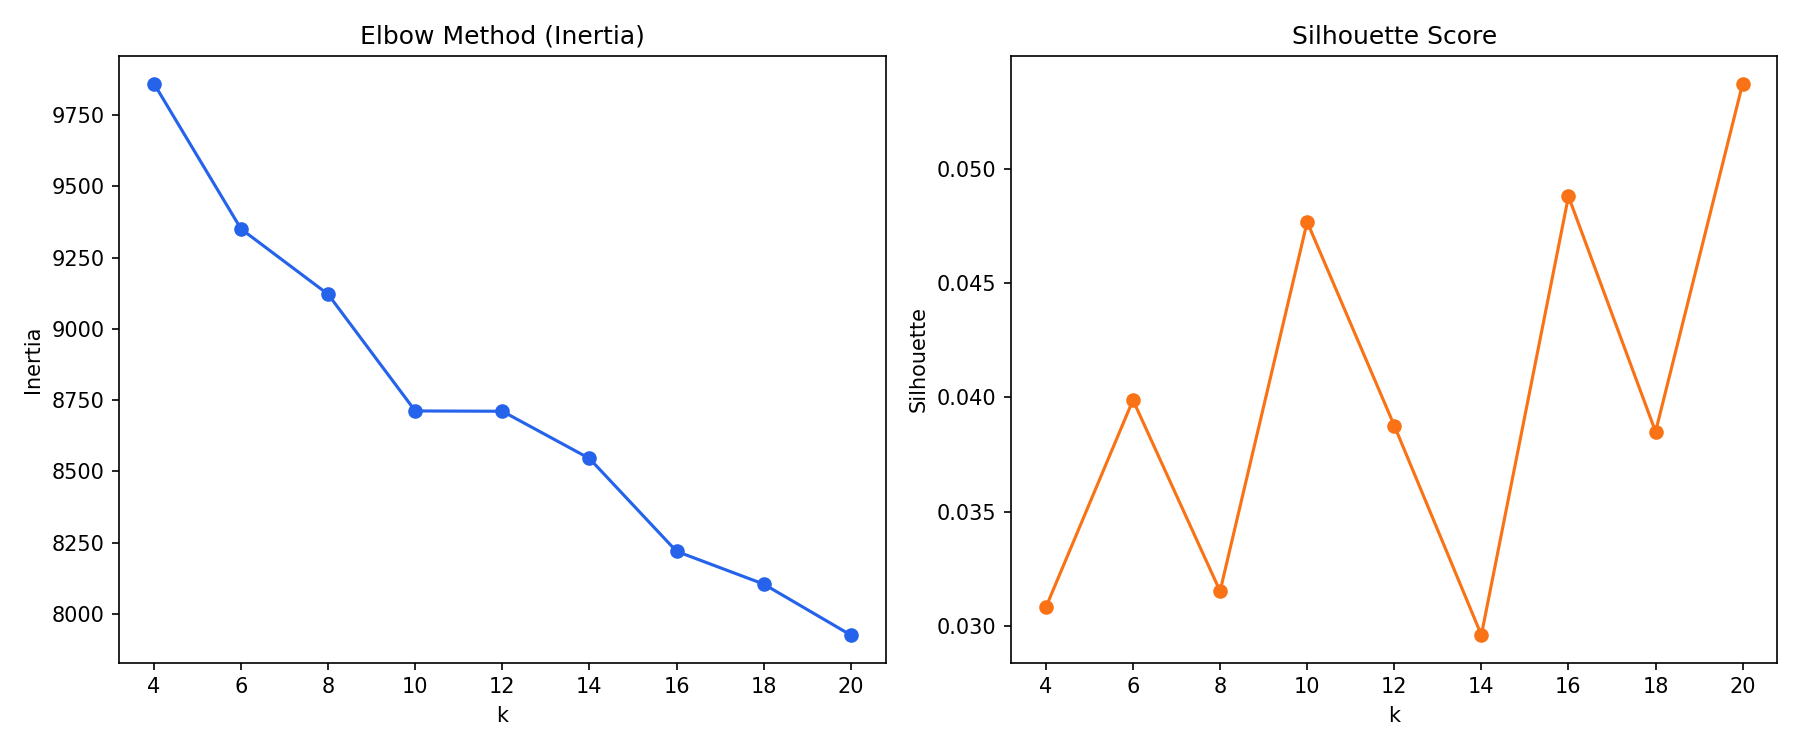

In [2]:
from src.config import FIGURES_DIR
from IPython.display import Image
Image(filename=str(FIGURES_DIR / 'clustering_k_selection.png'))

## Cluster visualization (PCA of SVD space)

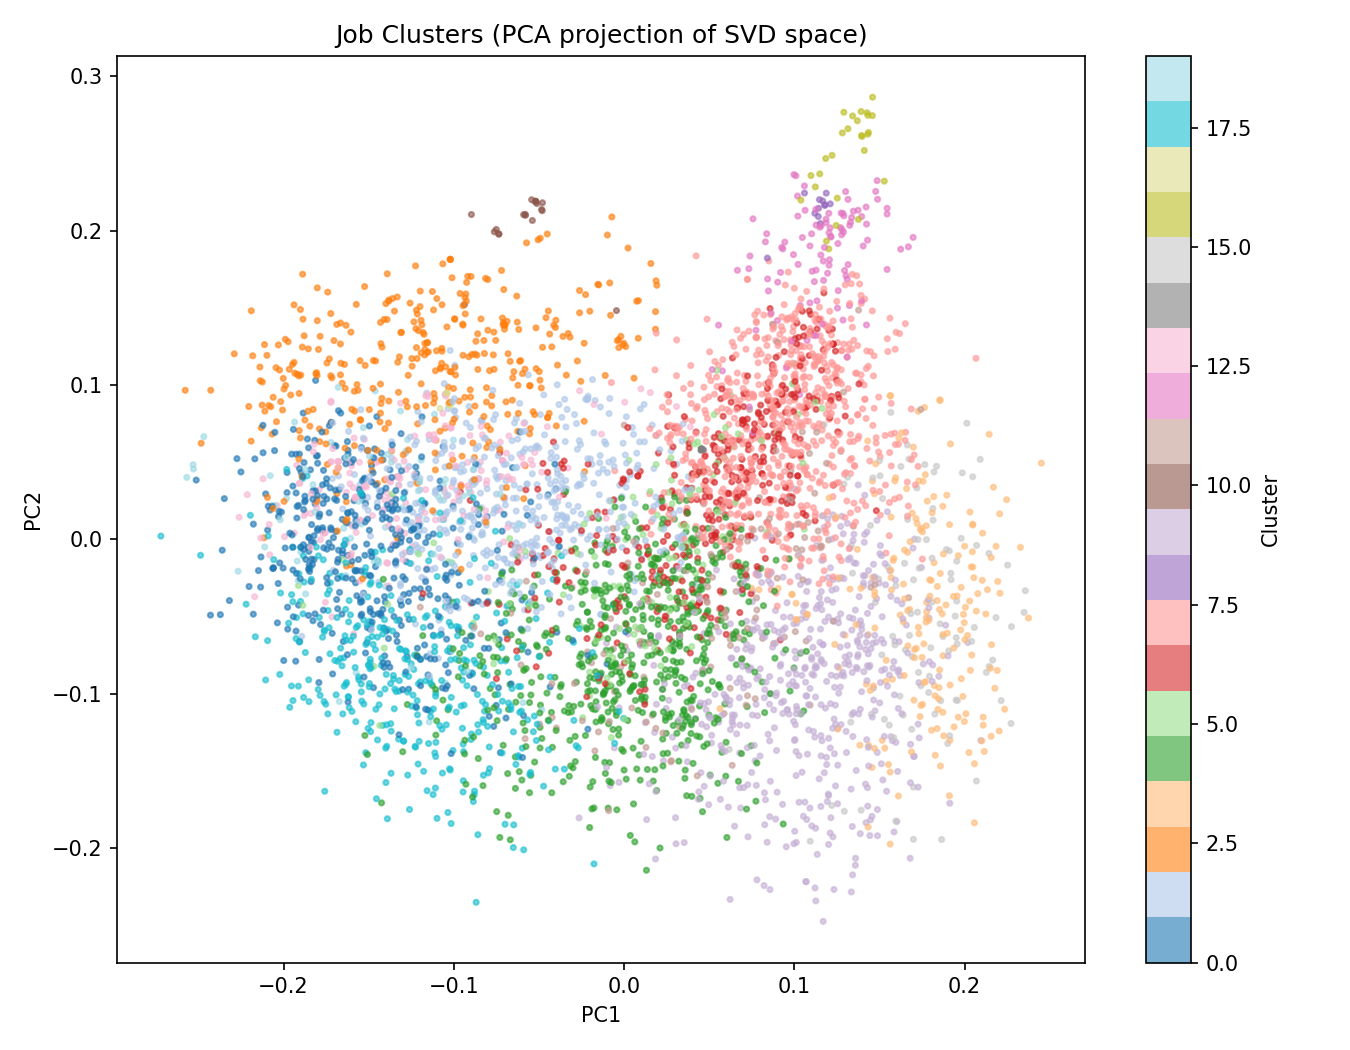

In [3]:
Image(filename=str(FIGURES_DIR / 'clustering_pca_scatter.png'))

## Top terms per cluster

In [4]:
import pandas as pd
assignments = pd.read_parquet('../models/job_clusters.parquet')
sizes = assignments['cluster'].value_counts().sort_index()
for cid, words in terms.items():
    print(f"Cluster {cid:2d} (n={sizes[cid]:5d}): {', '.join(words[:8])}")

Cluster  0 (n= 6034): status, employment, gender, protected, disability, national, origin, race
Cluster  1 (n= 7059): work, service, time, equipment, experience, position, required, company
Cluster  2 (n= 5042): care, patient, health, patients, nursing, health care, nurse, provider
Cluster  3 (n= 2864): developer, web, net, javascript, php, css, html, jquery
Cluster  4 (n= 7916): project, management, business, experience, team, skills, projects, work
Cluster  5 (n= 2057): accounting, financial, finance, accounts, accountant, tax, auditing, accounting auditing
Cluster  6 (n= 5481): sales, business, manager, business development, marketing, new, development, customer
Cluster  7 (n=10354): candidate, experience, profile, good, years, job, location, candidate profile
Cluster  8 (n=  189): incentives, inbound, fixed, fixed salary, bonus rs, calls, loyalty bonus, tech
Cluster  9 (n= 7893): experience, design, software, data, development, technical, engineer, knowledge
Cluster 10 (n=  294): n

## Skill-gap report
For a candidate resume: predict its nearest job cluster, extract that cluster's most common skills (from a curated skill vocabulary matched against job text), and compare against the candidate's own extracted skills to find matched vs. missing skills.

In [5]:
from src.models.skill_gap import skill_gap_report
resumes = pd.read_parquet('../data/processed/resumes_clean.parquet')

sample = resumes[resumes['category']=='Information-Technology'].iloc[0]
report = skill_gap_report(sample['resume_text_clean'])
print('Assigned cluster:', report['cluster_id'])
print('Candidate skills:', report['candidate_skills'])
print('Target cluster top skills:', report['target_cluster_top_skills'])
print('\nAlready has:', report['matched_skills'])
print('Skill gap (missing):', report['missing_skills'])

Assigned cluster: 9
Candidate skills: ['compliance', 'html', 'illustrator', 'linux']
Target cluster top skills: ['communication', 'sql', 'python', 'agile', 'java', 'linux', 'aws', 'azure', 'leadership', 'javascript', 'git', 'devops', 'scrum', 'compliance', 'machine learning']

Already has: ['compliance', 'linux']
Skill gap (missing): ['communication', 'sql', 'python', 'agile', 'java', 'aws', 'azure', 'leadership', 'javascript', 'git', 'devops', 'scrum', 'machine learning']


## Takeaways
- K-Means with k=20 (selected by silhouette) produces interpretable, mostly-coherent clusters: nursing/healthcare, Java development, web development, marketing, accounting, BPO/call-center, sales/retail, and several general/generic-language clusters.
- A handful of clusters are dominated by boilerplate EEO/legal language rather than job-specific content -- a limitation of using raw job descriptions without more aggressive boilerplate removal.
- The skill-gap module gives directionally sensible advice (e.g. an IT resume gets shown IT-adjacent missing skills), though it's bounded by the size of the curated skill vocabulary -- skills outside that list are invisible to both candidate-skill extraction and cluster-skill extraction.